In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.ensemble import GradientBoostingClassifier



file_path = "/Users/kyle/stock-trading-analytics-/data/spy_5y.csv"
df_csv = pd.read_csv(file_path)

In [4]:
df_csv = df_csv.drop([0]).reset_index(drop=True)
df_csv = df_csv.rename(columns={'Price': 'Date'})
column_order = ['Date', 'Open', 'Close', 'High', 'Low', 'Volume']
df_reordered = df_csv[column_order].copy()
df_reordered.dropna(inplace=True) 
df = df_reordered
df = df_csv[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()

df['Open'] = pd.to_numeric(df_csv['Open'], errors='coerce')
df['Low'] = pd.to_numeric(df_csv['Low'], errors='coerce')
df['High'] = pd.to_numeric(df_csv['High'], errors='coerce')
df['Volume'] = pd.to_numeric(df_csv['Volume'], errors='coerce')
df['Close'] = pd.to_numeric(df_csv['Close'], errors='coerce')

In [5]:
df['Daily Return'] = df['Close'].pct_change()
df['Rolling Volatility'] = df['Daily Return'].rolling(window=21).std()

df['MA_10'] = df['Close'].rolling(window=10).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()
df['MA_200'] = df['Close'].rolling(window=200).mean()

df['H-L'] = df['High'] - df['Low']
df['H-PC'] = abs(df['High'] - df['Close'].shift(1))
df['L-PC'] = abs(df['Low'] - df['Close'].shift(1))
df['TR'] = df[['H-L', 'H-PC', 'L-PC']].max(axis=1)
df['ATR_14'] = df['TR'].rolling(window=14).mean()

In [6]:
# Modeling, predicting whether SPY will go up or down 

df['Target'] = (df['Daily Return'].shift(-1) > 0).astype(int)

# Adding lag features
df['Lag_1'] = df['Daily Return'].shift(1)
df['Lag_2'] = df['Daily Return'].shift(2)
df['Lag_3'] = df['Daily Return'].shift(3)

# preparing final dataset
features = ['Lag_1', 'Lag_2', 'Lag_3', 'Rolling Volatility', 'MA_10', 'MA_50', 'ATR_14']
df_model = df[features + ['Target']].dropna()

In [7]:
# time-based train/test split

train_size = int(len(df_model) * 0.7)
X_train = df_model[features].iloc[:train_size]
X_test = df_model[features].iloc[train_size:]
y_train = df_model['Target'].iloc[:train_size]
y_test = df_model['Target'].iloc[train_size:]

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [8]:
# Predict and Evalulate Mode

y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

# Optional: full report
print(classification_report(y_test, y_pred))

Accuracy: 0.4214876033057851
Precision: 0.5416666666666666
Recall: 0.06132075471698113
F1 Score: 0.11016949152542373
              precision    recall  f1-score   support

           0       0.41      0.93      0.57       151
           1       0.54      0.06      0.11       212

    accuracy                           0.42       363
   macro avg       0.48      0.49      0.34       363
weighted avg       0.49      0.42      0.30       363



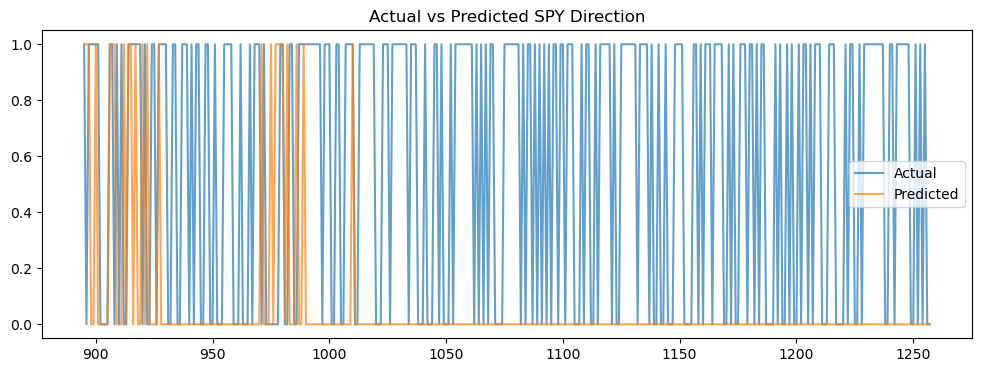

In [9]:
# Further analysis of visualizing predicted vs actual direction

results = X_test.copy()
results['Actual'] = y_test
results['Predicted'] = y_pred
results[['Actual', 'Predicted']].plot(figsize=(12, 4), alpha=0.7)
plt.title("Actual vs Predicted SPY Direction")
plt.show()

In [10]:
# Save predicitions with dates

results = df_model.iloc[train_size:].copy()
results['Predicted'] = y_pred
results['Correct'] = (results['Predicted'] == results['Target']).astype(int)

In [11]:
# Simulate Strategy Returns

# Use the actual return shifted (because prediction is made at t, executed at t+1)
results['Strategy Return'] = results['Predicted'] * df['Daily Return'].iloc[train_size:]
results['SPY Return'] = df['Daily Return'].iloc[train_size:]

results['Strategy Cumulative'] = (1 + results['Strategy Return']).cumprod()
results['SPY Cumulative'] = (1 + results['SPY Return']).cumprod()

<Axes: title={'center': 'Strategy vs Buy-and-Hold'}>

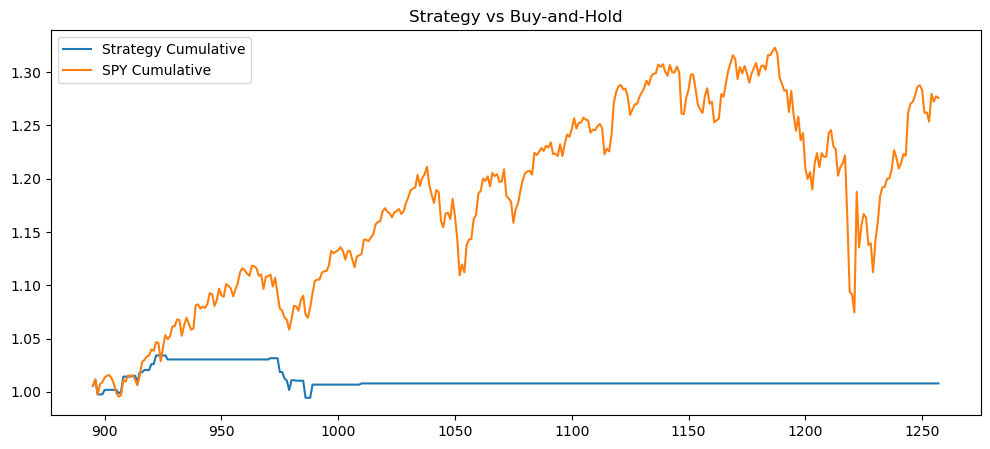

In [12]:
# Visualize Strategy VS SPY

results[['Strategy Cumulative', 'SPY Cumulative']].plot(figsize=(12, 5), title='Strategy vs Buy-and-Hold')

In [13]:
# Evaluate for Strategy 

total_return_strategy = results['Strategy Cumulative'].iloc[-1] - 1
total_return_spy = results['SPY Cumulative'].iloc[-1] - 1

print(f"Strategy Total Return: {total_return_strategy:.2%}")
print(f"SPY Buy-and-Hold Return: {total_return_spy:.2%}")

Strategy Total Return: 0.80%
SPY Buy-and-Hold Return: 27.57%


In [14]:
# Export for Reporting

export_path = "/Users/kyle/stock-trading-analytics-/data/model_results.csv"
results.to_csv(export_path)
print(f"Exported to {export_path}")

Exported to /Users/kyle/stock-trading-analytics-/data/model_results.csv


In [15]:
# training next model

features = ['Lag_1', 'Lag_2', 'Lag_3', 'Rolling Volatility', 'MA_10', 'MA_50', 'ATR_14']
df_model = df[features + ['Target']].dropna()  # Changed 'pd' to 'df'

X = df_model[features]
y = df_model['Target']

train_size = int(len(X) * 0.7)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [16]:
# train random forest

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.43      0.89      0.58       151
           1       0.66      0.15      0.24       212

    accuracy                           0.46       363
   macro avg       0.54      0.52      0.41       363
weighted avg       0.56      0.46      0.38       363



In [17]:
# train graident boosting

gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.42      0.93      0.58       151
           1       0.65      0.09      0.16       212

    accuracy                           0.44       363
   macro avg       0.53      0.51      0.37       363
weighted avg       0.55      0.44      0.34       363



In [18]:
# features enhancement

delta = df['Close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain / avg_loss
df['RSI_14'] = 100 - (100 / (1 + rs))

# macd 12 26 9 ema

ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = ema_12 - ema_26
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

# rolling sharpe ratio

risk_free_rate = 0.01  # annualized
daily_rf = (1 + risk_free_rate)**(1/252) - 1
df['Excess Return'] = df['Daily Return'] - daily_rf

rolling_mean = df['Excess Return'].rolling(window=21).mean()
rolling_std = df['Excess Return'].rolling(window=21).std()
df['Sharpe_21'] = rolling_mean / rolling_std

In [40]:
# export model results

results = X_test.copy()
results['Predicted_RF'] = y_pred_rf
results['Actual'] = y_test
results['Daily Return'] = df['Daily Return'].iloc[train_size:]
results['Strategy Return'] = results['Predicted_RF'] * results['Daily Return']
results['SPY Return'] = results['Daily Return']
results['Strategy Cumulative'] = (1 + results['Strategy Return']).cumprod()
results['SPY Cumulative'] = (1 + results['SPY Return']).cumprod()
results.index.name = "Date"

results.to_csv("/Users/kyle/stock-trading-analytics-/data/model_results.csv", index=True)

In [41]:
import pandas as pd

# Load the file and skip the metadata rows
file_path = "/Users/kyle/stock-trading-analytics-/data/spy_5y.csv"
df_raw = pd.read_csv(file_path, skiprows=2)

# Rename the columns properly
df_raw = df_raw.rename(columns={
    'Price': 'Date',
    'Close': 'Close',
    'High': 'High',
    'Low': 'Low',
    'Open': 'Open',
    'Volume': 'Volume'
})

# Convert Date to datetime
df_raw['Date'] = pd.to_datetime(df_raw['Date'])
df_raw.set_index('Date', inplace=True)

# Convert all numeric columns to float
for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

df_raw.dropna(inplace=True)
df = df_raw.copy()

KeyError: 'Open'

In [42]:
# export model results, debugging 07 22 25 

import pandas as pd

# Load and fix the CSV
file_path = "/Users/kyle/stock-trading-analytics-/data/spy_5y.csv"
df = pd.read_csv(file_path, skiprows=3, header=None)

# Set the correct column names
df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Set Date as index
df.set_index('Date', inplace=True)

# Convert all price and volume columns to numeric
for col in ['Close', 'High', 'Low', 'Open', 'Volume']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop any rows with missing data
df.dropna(inplace=True)

# Preview
print(df.head())

                 Close        High         Low        Open     Volume
Date                                                                 
2020-06-01  284.094025  284.707682  281.778884  282.299558   55758300
2020-06-02  286.446320  286.492826  283.675596  285.023759   74267200
2020-06-03  290.258423  291.225401  288.175727  288.454649   92567600
2020-06-04  289.496063  291.020915  287.376168  289.263618   75794400
2020-06-05  296.915680  298.710147  294.888768  294.953859  150524700


In [49]:
# Calculate daily returns (price change % from previous day)
df['Daily Return'] = df['Close'].pct_change()

# Lag features
df['Lag_1'] = df['Daily Return'].shift(1)
df['Lag_2'] = df['Daily Return'].shift(2)
df['Lag_3'] = df['Daily Return'].shift(3)

# Rolling indicators (if not already in your pipeline)
df['MA_10'] = df['Close'].rolling(window=10).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()
df['Rolling Volatility'] = df['Daily Return'].rolling(window=21).std()

# ATR - Average True Range
df['H-L'] = df['High'] - df['Low']
df['H-PC'] = abs(df['High'] - df['Close'].shift(1))
df['L-PC'] = abs(df['Low'] - df['Close'].shift(1))
df['TR'] = df[['H-L', 'H-PC', 'L-PC']].max(axis=1)
df['ATR_14'] = df['TR'].rolling(window=14).mean()

In [51]:
print("df shape:", df.shape)
print("df index dtype:", df.index.dtype)
print("df.index sample:", df.index[:5])

print("X_test shape:", X_test.shape)
print("X_test index dtype:", X_test.index.dtype)
print("X_test.index sample:", X_test.index[:5])

print("y_test shape:", y_test.shape)

print("Does df contain 'Daily Return'?", 'Daily Return' in df.columns)

df shape: (1257, 17)
df index dtype: datetime64[ns]
df.index sample: DatetimeIndex(['2020-06-01', '2020-06-02', '2020-06-03', '2020-06-04',
               '2020-06-05'],
              dtype='datetime64[ns]', name='Date', freq=None)
X_test shape: (363, 7)
X_test index dtype: int64
X_test.index sample: Index([895, 896, 897, 898, 899], dtype='int64')
y_test shape: (363,)
Does df contain 'Daily Return'? True


In [52]:
# Get the actual datetime index from the test set slice of df
actual_dates = df.iloc[train_size:].index[:len(X_test)]

# Build results DataFrame using X_test
results = X_test.copy()
results.index = actual_dates  # set correct datetime index

# Add predictions and actuals
results['Predicted_RF'] = y_pred_rf
results['Actual'] = y_test.values
results['Correct'] = (results['Predicted_RF'] == results['Actual']).astype(int)

# Add return calculations
results['Daily Return'] = df['Daily Return'].iloc[train_size:].values[:len(X_test)]
results['Strategy Return'] = results['Predicted_RF'] * results['Daily Return']
results['SPY Return'] = results['Daily Return']
results['Strategy Cumulative'] = (1 + results['Strategy Return']).cumprod()
results['SPY Cumulative'] = (1 + results['SPY Return']).cumprod()

# Move index to column
results.reset_index(inplace=True)
results.rename(columns={'index': 'Date'}, inplace=True)

# Export
results.to_csv("/Users/kyle/stock-trading-analytics-/data/model_results.csv", index=False)

In [50]:
# Ensure df.index is datetime
df.index = pd.to_datetime(df.index)

# Align index with X_test to avoid length mismatch
aligned_daily_return = df.loc[X_test.index, 'Daily Return']

# Build the results DataFrame
results = X_test.copy()
results['Predicted_RF'] = y_pred_rf
results['Actual'] = y_test
results['Correct'] = (results['Predicted_RF'] == results['Actual']).astype(int)
results['Daily Return'] = aligned_daily_return
results['Strategy Return'] = results['Predicted_RF'] * results['Daily Return']
results['SPY Return'] = results['Daily Return']
results['Strategy Cumulative'] = (1 + results['Strategy Return']).cumprod()
results['SPY Cumulative'] = (1 + results['SPY Return']).cumprod()

# Export with datetime index as column
results = results.reset_index().rename(columns={'index': 'Date'})
results.to_csv("/Users/kyle/stock-trading-analytics-/data/model_results.csv", index=False)

KeyError: "None of [Index([ 895,  896,  897,  898,  899,  900,  901,  902,  903,  904,\n       ...\n       1248, 1249, 1250, 1251, 1252, 1253, 1254, 1255, 1256, 1257],\n      dtype='int64', length=363)] are in the [index]"